# World Models with Python: Atari game

### Env

In [19]:
import gymnasium as gym
import ale_py

env = gym.make("ALE/BattleZone-v5")

N_ACTIONS = env.action_space.n
print("Actions:", N_ACTIONS)

Actions: 18


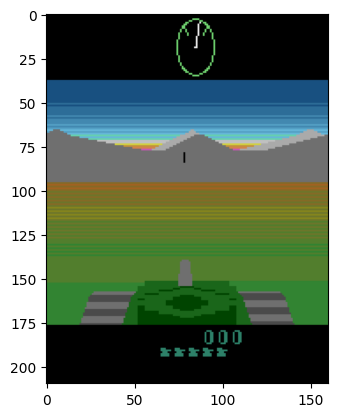

In [22]:
import matplotlib.pyplot as plt

obs, _ = env.reset()
plt.imshow(obs)
plt.show()

In [2]:
import torch
import torch.nn.functional as F

IMAGE_SIZE = 64

def preprocess(obs):
    """
    Atari RGB image
    -> grayscale
    -> 64x64
    -> [0,1]
    """
    x = torch.tensor(obs, dtype=torch.float32,)
    # HWC -> CHW
    x = x.permute(2, 0, 1)
    # RGB -> grayscale
    x = x.mean(dim=0, keepdim=True,)
    # 64x64
    x = F.interpolate(
        x.unsqueeze(0),
        size=(IMAGE_SIZE, IMAGE_SIZE),
        mode="bilinear",
        align_corners=False,
    )
    return x.squeeze(0) / 255.0

obs, _ = env.reset()
preprocess(obs) 

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]])

In [3]:
import random
from collections import deque

BUFFER_SIZE = 20_000

class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def add(self, obs, action, next_obs):
        self.buffer.append((obs, action, next_obs))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        obs, actions, next_obs = zip(*batch)
        return (
            torch.stack(obs),
            torch.tensor(actions, dtype=torch.long),
            torch.stack(next_obs)
        )

    def __len__(self):
        return len(self.buffer)

buffer = ReplayBuffer(BUFFER_SIZE)

# PLAY RANDOM TO COLLECT DATA INTO THE BUFFER
obs, _ = env.reset()

for step in range(BUFFER_SIZE):
    action = env.action_space.sample() #random action
    next_obs, reward, terminated, truncated, _ = env.step(action)
    buffer.add(
        preprocess(obs),
        action,
        preprocess(next_obs),
    )
    obs = next_obs
    
    if terminated or truncated:
        obs, _ = env.reset()
        
    if step % 2_000 == 0:
        print(f"Collected {step:,} / {BUFFER_SIZE:,}")

print("Buffer:", len(buffer))

Collected 0 / 20,000
Collected 2,000 / 20,000
Collected 4,000 / 20,000
Collected 6,000 / 20,000
Collected 8,000 / 20,000
Collected 10,000 / 20,000
Collected 12,000 / 20,000
Collected 14,000 / 20,000
Collected 16,000 / 20,000
Collected 18,000 / 20,000
Buffer: 20000


### Model

In [11]:
import torch.nn as nn

LATENT_SIZE = 128

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32,  kernel_size=4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32,64,  kernel_size=4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64,128, kernel_size=4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(128,128,kernel_size=4, stride=2, padding=1), nn.ReLU(),
        )
        self.fc = nn.Linear(128*4*4, LATENT_SIZE,)

    def forward(self, x):
        x = self.conv(x)
        x = x.flatten(1)
        return self.fc(x)


class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(LATENT_SIZE, 128*4*4,)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(128,128,kernel_size=4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(128, 64,kernel_size=4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(32, 1,  kernel_size=4, stride=2, padding=1), nn.Sigmoid(),
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1,128,4,4)
        return self.net(x)

In [12]:
class Dynamics(nn.Module):
    def __init__(self):
        super().__init__()
        self.action_embedding = nn.Embedding(N_ACTIONS,32,)
        self.net = nn.Sequential(
            nn.Linear(LATENT_SIZE+32,256,), nn.ReLU(),
            nn.Linear(256,256,), nn.ReLU(),
            nn.Linear(256, LATENT_SIZE,),
       )

    def forward(self, latent, action,):
        action = self.action_embedding(action)
        x = torch.cat([latent,action,], dim=1,)
        return self.net(x)

### Train

In [13]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LR = 1e-3
TRAIN_STEPS = 20_000
BATCH_SIZE = 64

# WORLD MODEL
encoder = Encoder().to(DEVICE)
dynamics = Dynamics().to(DEVICE)
decoder = Decoder().to(DEVICE)
optimizer = torch.optim.Adam(
    list(encoder.parameters())
    + list(dynamics.parameters())
    + list(decoder.parameters()),
    lr=LR,
)

# TRAIN
for step in range(TRAIN_STEPS):
    obs, actions, next_obs = buffer.sample(BATCH_SIZE)
    obs = obs.to(DEVICE)
    actions = actions.to(DEVICE)
    next_obs = next_obs.to(DEVICE)
    
    ##States
    z = encoder(obs) #Current latent state
    predicted_z = dynamics(z,actions) #Predict future latent state
    with torch.no_grad():
        target_z = encoder(next_obs) #Real future latent state
    latent_loss = F.mse_loss(predicted_z, target_z) #Prediction loss
    
    ##Obs
    predicted_next_obs = decoder(predicted_z) #Reconstruct predicted future
    image_loss = F.mse_loss(predicted_next_obs, next_obs) #Pixel reconstruction loss

    ##Loss = state loss + obs loss
    loss = (latent_loss + 0.5*image_loss)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if step % 1_000 == 0:
        print(
            f"step={step:05d} "
            f"loss={loss.item():.4f} "
            f"latent={latent_loss.item():.4f} "
            f"image={image_loss.item():.4f}"
        )

# SAVE
torch.save({
    "encoder":encoder.state_dict(),
    "dynamics": dynamics.state_dict(),
    "decoder": decoder.state_dict(),
    }, "battlezone_world_model.pt"
)
print("\nSaved: battlezone_world_model.pt")

step=00000 loss=0.0443 latent=0.0041 image=0.0804
step=01000 loss=0.0068 latent=0.0032 image=0.0072
step=02000 loss=0.0011 latent=0.0002 image=0.0019
step=03000 loss=0.0064 latent=0.0050 image=0.0029
step=04000 loss=0.0011 latent=0.0003 image=0.0016
step=05000 loss=0.0299 latent=0.0285 image=0.0026
step=06000 loss=0.0014 latent=0.0001 image=0.0026
step=07000 loss=0.0018 latent=0.0002 image=0.0033
step=08000 loss=0.0019 latent=0.0002 image=0.0035
step=09000 loss=0.0026 latent=0.0006 image=0.0040
step=10000 loss=0.0021 latent=0.0000 image=0.0041
step=11000 loss=0.0029 latent=0.0000 image=0.0058
step=12000 loss=0.0018 latent=0.0000 image=0.0036
step=13000 loss=0.0019 latent=0.0000 image=0.0038
step=14000 loss=0.0018 latent=0.0000 image=0.0037
step=15000 loss=0.0015 latent=0.0000 image=0.0030
step=16000 loss=0.0041 latent=0.0000 image=0.0081
step=17000 loss=0.0035 latent=0.0000 image=0.0070
step=18000 loss=0.0022 latent=0.0000 image=0.0044
step=19000 loss=0.0014 latent=0.0000 image=0.0028


### Test

Testing action: 10


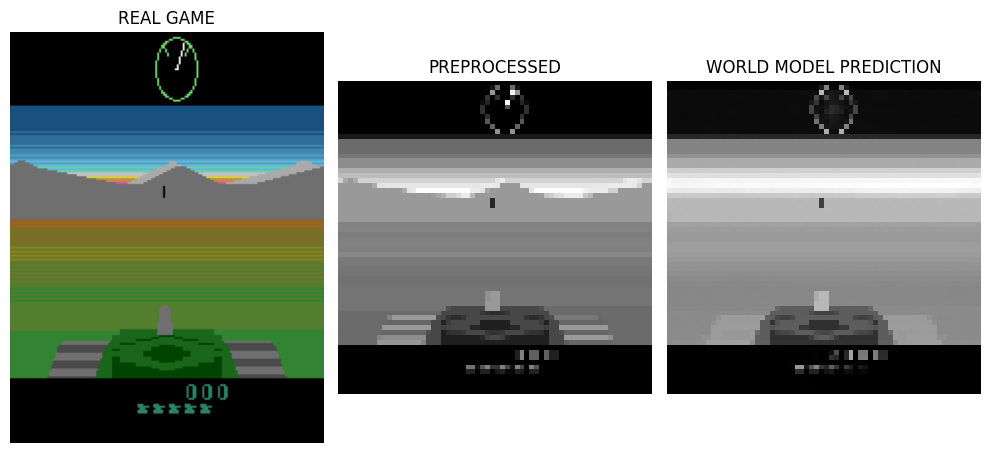

In [34]:
# LOAD
checkpoint = torch.load("battlezone_world_model.pt", map_location=DEVICE)

encoder = Encoder().to(DEVICE)
dynamics = Dynamics().to(DEVICE)
decoder = Decoder().to(DEVICE)

encoder.load_state_dict(checkpoint["encoder"])
dynamics.load_state_dict(checkpoint["dynamics"])
decoder.load_state_dict(checkpoint["decoder"])

encoder.eval()
dynamics.eval()
decoder.eval()

# REAL OBSERVATION
obs, _ = env.reset()
real_frame = preprocess(obs)
frame = real_frame.unsqueeze(0).to(DEVICE) #add batch dimension

with torch.no_grad():
    z = encoder(frame)

action = env.action_space.sample() #random action
print("Testing action:", action)

real_next_obs, reward, terminated, truncated, _ = env.step(action)
real_next_frame = preprocess(real_next_obs).unsqueeze(0).to(DEVICE)

# MODEL PREDICTION
with torch.no_grad():
    predicted_z = dynamics(z, torch.tensor([action], device=DEVICE))
    predicted_frame = decoder(predicted_z)

# VISUAL COMPARISON
fig, axes = plt.subplots(1, 3, figsize=(10,5))

axes[0].imshow(real_next_obs)
axes[0].set_title("REAL GAME")
axes[0].axis("off")

axes[1].imshow(real_next_frame[0,0].cpu(), cmap="gray")
axes[1].set_title("PREPROCESSED")
axes[1].axis("off")

axes[2].imshow(predicted_frame[0,0].cpu(), cmap="gray")
axes[2].set_title("WORLD MODEL PREDICTION")
axes[2].axis("off")

plt.tight_layout()
plt.show()

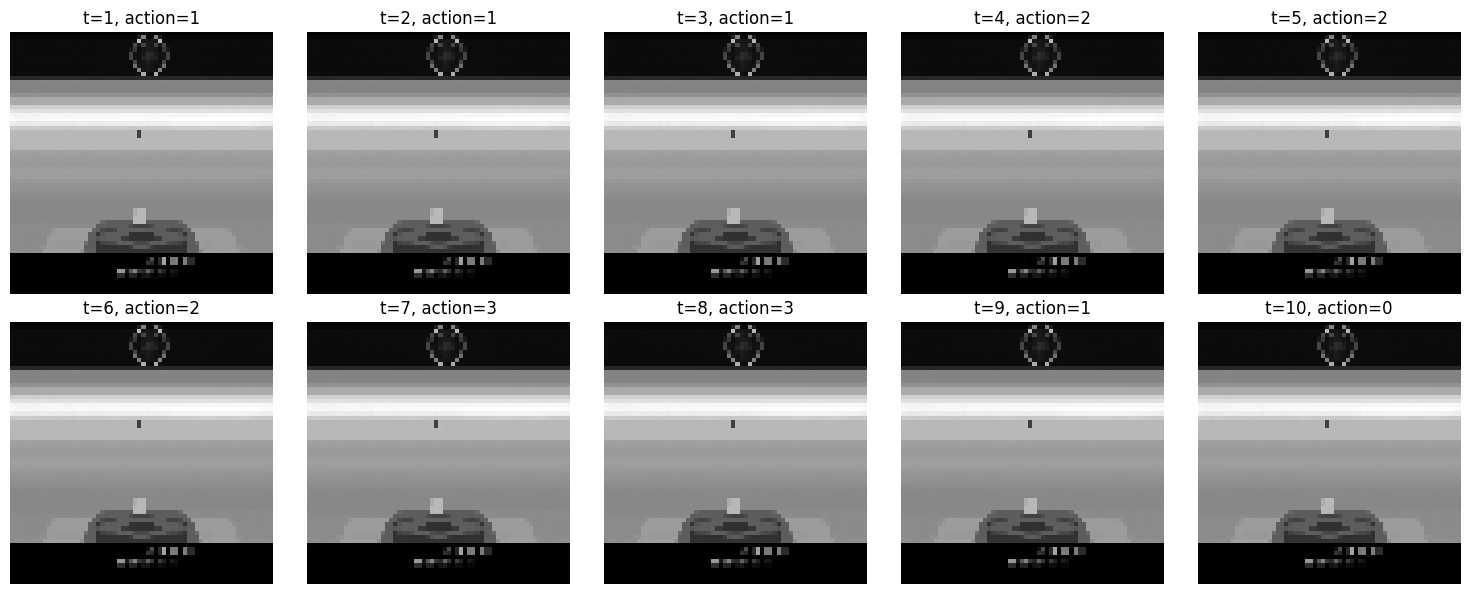

In [15]:
# ------------------------------------------------------------
# IMAGINED ROLLOUT
# ------------------------------------------------------------

obs, _ = env.reset()

z = encoder(
    preprocess(obs)
    .unsqueeze(0)
    .to(DEVICE)
)

actions = [
    1, 1, 1, 2, 2,
    2, 3, 3, 1, 0
]

frames = []

with torch.no_grad():

    for action in actions:

        action_tensor = torch.tensor(
            [action],
            device=DEVICE,
        )

        # Predict next latent state
        z = dynamics(
            z,
            action_tensor,
        )

        # Decode into pixels
        predicted_frame = decoder(z)

        frames.append(
            predicted_frame[0, 0].cpu().numpy()
        )


# ------------------------------------------------------------
# DISPLAY IMAGINED FUTURE
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    5,
    figsize=(15, 6),
)

for i, ax in enumerate(
    axes.flat
):

    ax.imshow(
        frames[i],
        cmap="gray",
    )

    ax.set_title(
        f"t={i+1}, action={actions[i]}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()